In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('D:\machine_learning\datasets\superstore_sales.csv')

In [3]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.dtypes

row_id             int64
order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
postal_code        int64
region            object
product_id        object
category          object
sub-category      object
product_name      object
sales            float64
quantity           int64
discount         float64
profit           float64
dtype: object

In [6]:
df.select_dtypes(include='number')

,row_id,postal_code,sales,quantity,discount,profit
0,1,42420,261.9600,2,0.00,41.9136
1,2,42420,731.9400,3,0.00,219.5820
2,3,90036,14.6200,2,0.00,6.8714
3,4,33311,957.5775,5,0.45,-383.0310
4,5,33311,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...
9989,9990,33180,25.2480,3,0.20,4.1028
9990,9991,92627,91.9600,2,0.00,15.6332
9991,9992,92627,258.5760,2,0.20,19.3932
9992,9993,92627,29.6000,4,0.00,13.3200


In [7]:
df.nunique().sort_values()

country             1
category            3
segment             3
region              4
ship_mode           4
discount           12
quantity           14
sub-category       17
state              49
city              531
postal_code       631
customer_id       793
customer_name     793
order_date       1237
ship_date        1334
product_name     1850
product_id       1862
order_id         5009
sales            5825
profit           7287
row_id           9994
dtype: int64

In [8]:
df[['country','category','segment','region','ship_mode']]

,country,category,segment,region,ship_mode
0,United States,Furniture,Consumer,South,Second Class
1,United States,Furniture,Consumer,South,Second Class
2,United States,Office Supplies,Corporate,West,Second Class
3,United States,Furniture,Consumer,South,Standard Class
4,United States,Office Supplies,Consumer,South,Standard Class
...,...,...,...,...,...
9989,United States,Furniture,Consumer,South,Second Class
9990,United States,Furniture,Consumer,West,Standard Class
9991,United States,Technology,Consumer,West,Standard Class
9992,United States,Office Supplies,Consumer,West,Standard Class


In [9]:
df.drop_duplicates()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,21/1/2014,23/1/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,26/2/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,26/2/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,26/2/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [11]:
# Convert Order Date and Ship Date to datetime
df['order_date']=pd.to_datetime(df['order_date'],format='mixed')

In [12]:
df['ship_date']=pd.to_datetime(df['ship_date'],format='mixed')

In [13]:
df

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [14]:
# Extracts year,month
df['OD_Year']=df['order_date'].dt.year

In [15]:
df['OD_Month']=df['order_date'].dt.month

In [16]:
df

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,OD_Year,OD_Month
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,8
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,8
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,12
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,11
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,1
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,2
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,2
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,2


In [17]:
df['SD_Year']=df['ship_date'].dt.year

In [18]:
df['SD_Month']=df['ship_date'].dt.month

In [19]:
df

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub-category,product_name,sales,quantity,discount,profit,OD_Year,OD_Month,SD_Year,SD_Month
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,8,2016,11
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,8,2016,11
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,12,2016,6
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,11,2015,10
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,11,2015,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,1,2014,1
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,2,2017,3
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,2,2017,3
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,2,2017,3


In [20]:
# Check if postal code is wrongly numeric
df['postal_code'].astype(float)

0       42420.0
1       42420.0
2       90036.0
3       33311.0
4       33311.0
         ...   
9989    33180.0
9990    92627.0
9991    92627.0
9992    92627.0
9993    92683.0
Name: postal_code, Length: 9994, dtype: float64

In [ ]:
# Detect outliers from sales,profit

def z_score(col):
    x=df[col]
    x_mean=df[col].mean()
    x_std=df[col].std()
    return(x-x_mean)/x_std
    
df['Sales_z']=z_score('sales')
df['Sales_z']

0       0.051508
1       0.805593
2      -0.345350
3       1.167630
4      -0.332919
          ...   
9989   -0.328298
9990   -0.221258
9991    0.046078
9992   -0.321315
9993    0.021343
Name: Sales_z, Length: 9994, dtype: float64

In [23]:
def outliers(col='Sales_z'):
    l=[]
    for val in df['Sales_z']:
        if abs(val)>3:
            l.append(val)
    return l

outliers()

[4.578571089994074,
 12.723876999108532,
 5.002064190516768,
 4.540948652239068,
 3.6744773401353044,
 6.036344282688982,
 6.619081314562273,
 3.476012242055842,
 4.021040834695806,
 9.827741917538233,
 4.444626996519668,
 12.467201094445288,
 4.540948652239068,
 3.98891543173049,
 3.337037062099664,
 7.493154772268359,
 3.2324714587009225,
 5.4248160096405025,
 3.5677328186850734,
 4.508887429481455,
 4.685270685298913,
 4.136385503978126,
 7.114180272818266,
 3.7643071678456304,
 6.049132189073637,
 3.476227887553721,
 6.92978090905881,
 12.76831858393189,
 3.9081927754931,
 17.601598456555678,
 3.4813623041698936,
 35.95475035564655,
 3.948866982124343,
 3.7226558175521225,
 4.1237420030608005,
 4.339339365784277,
 5.022252074849483,
 6.312431491171743,
 3.6500599801150173,
 3.4743024813226557,
 3.5302676224389384,
 4.1237420030608005,
 3.789363120932553,
 4.573067637183613,
 14.793685488492768,
 3.84299370699367,
 16.47844803077828,
 7.33279089629336,
 14.232076580995026,
 6.639503

In [24]:
len(outliers())

127

{'whiskers': [<matplotlib.lines.Line2D at 0x15e880fbed0>,
 'caps': [<matplotlib.lines.Line2D at 0x15e881c2850>,
 'boxes': [<matplotlib.lines.Line2D at 0x15e880fa490>],
 'medians': [<matplotlib.lines.Line2D at 0x15e881c2ad0>],
 'fliers': [<matplotlib.lines.Line2D at 0x15e881c2c10>],
 'means': []}

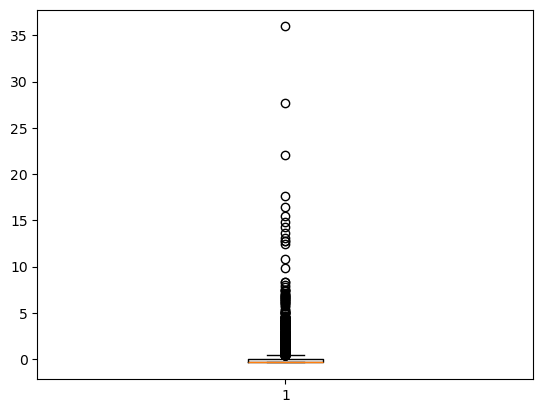

In [25]:
plt.boxplot(df['Sales_z'])

In [26]:
df['Profit_z']=z_score('profit')

In [29]:
def outliers(col='Profit_z'):
    l=[]
    for val in df['Profit_z']:
        if abs(val)>3:
            l.append(val)
    return l
outliers()

[-7.230036360019832,
 -5.927807811561876,
 -4.179358175653977,
 8.398071370681583,
 5.919798796992292,
 -3.5991620793587207,
 13.441546385038905,
 5.768460183049666,
 -16.514323904484034,
 -3.370769799822237,
 3.418074513773149,
 5.3266867158551285,
 3.131252738344615,
 10.12681513329547,
 -8.023573944512181,
 -3.480750112961974,
 6.106644096567341,
 6.197428226266692,
 -4.601711776423789,
 3.4769629012838346,
 -3.392250196333615,
 4.82936943401689,
 5.120469786834803,
 16.611159031932864,
 -4.117715157803707,
 -7.853387051007483,
 -5.005324670364458,
 5.276609047422243,
 -5.699678487594769,
 -14.636025442415223,
 3.6127815872462508,
 3.259676652670175,
 -11.391816227747745,
 4.3598037828940965,
 3.152664834708104,
 -6.440236074244834,
 3.1108766698494317,
 3.047787823243516,
 3.9115904655053892,
 5.925648704659063,
 19.644055699671505,
 -4.156283824441218,
 21.392155724197394,
 9.977477286810092,
 -4.6701459633539395,
 4.180508210916431,
 3.087617054485521,
 -5.1649395547276455,
 3.47

In [30]:
len(outliers())

107

{'whiskers': [<matplotlib.lines.Line2D at 0x15e8843ca50>,
 'caps': [<matplotlib.lines.Line2D at 0x15e8843ccd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x15e8843c910>],
 'medians': [<matplotlib.lines.Line2D at 0x15e8843cf50>],
 'fliers': [<matplotlib.lines.Line2D at 0x15e8843d090>],
 'means': []}

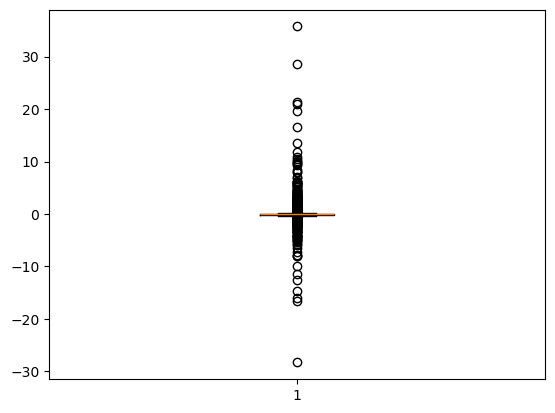

In [32]:
plt.boxplot(df['Profit_z'])

In [33]:
df['segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [34]:
df['segment'].str.replace(' ','')

0        Consumer
1        Consumer
2       Corporate
3        Consumer
4        Consumer
          ...    
9989     Consumer
9990     Consumer
9991     Consumer
9992     Consumer
9993     Consumer
Name: segment, Length: 9994, dtype: object

In [35]:
df=df.drop(columns=['row_id','customer_id'])

In [36]:
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,city,state,postal_code,...,sales,quantity,discount,profit,OD_Year,OD_Month,SD_Year,SD_Month,Sales_z,Profit_z
0,CA-2016-152156,2016-08-11,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,261.9600,2,0.00,41.9136,2016,8,2016,11,0.051508,0.056590
1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,731.9400,3,0.00,219.5820,2016,8,2016,11,0.805593,0.815013
2,CA-2016-138688,2016-12-06,2016-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,...,14.6200,2,0.00,6.8714,2016,12,2016,6,-0.345350,-0.092997
3,US-2015-108966,2015-11-10,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,957.5775,5,0.45,-383.0310,2015,11,2015,10,1.167630,-1.757397
4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,22.3680,2,0.20,2.5164,2015,11,2015,10,-0.332919,-0.111587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,...,25.2480,3,0.20,4.1028,2014,1,2014,1,-0.328298,-0.104816
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,...,91.9600,2,0.00,15.6332,2017,2,2017,3,-0.221258,-0.055595
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,...,258.5760,2,0.20,19.3932,2017,2,2017,3,0.046078,-0.039544
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,...,29.6000,4,0.00,13.3200,2017,2,2017,3,-0.321315,-0.065470


In [37]:
df.to_csv('cleaned.csv') # To save all the changes in the csv format

([<matplotlib.patches.Wedge at 0x15e881bd010>,
 [Text(0.5806250883943506, 0.9342775319609546, 'Furniture'),
  Text(-1.0908936259884885, 0.14124835141582345, 'Office Supplies'),
  Text(0.45584989144183646, -1.0010998334194579, 'Technology')],
 [Text(0.31670459366964576, 0.509605926524157, '32.3%'),
  Text(-0.5950328869028119, 0.07704455531772188, '31.3%'),
  Text(0.24864539533191077, -0.5460544545924314, '36.4%')])

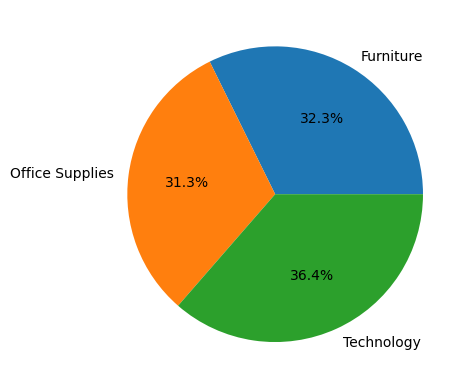

In [40]:
total_sales=df.groupby('category')['sales'].sum()
plt.pie(total_sales.values,labels=total_sales.index,autopct='%1.1f%%')

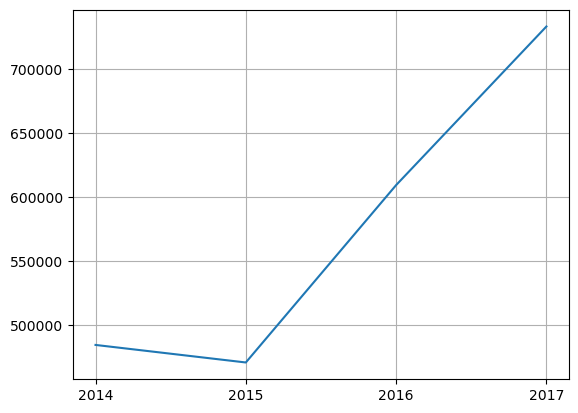

In [ ]:
# Sales Trend Over Time
year_sales=df.groupby('OD_Year')['sales'].sum()
plt.plot(year_sales)
plt.xticks(year_sales.index)
plt.grid()
plt.show()

([<matplotlib.patches.Wedge at 0x15e8960c410>,
 [Text(0.8515248110380425, 0.6963515607698645, 'Central'),
  Text(-0.7322877267658412, 0.8208256119469696, 'East'),
  Text(-0.8942110727064594, -0.640614203283976, 'South'),
  Text(0.6016104300236751, -0.9209043872665224, 'West')],
 [Text(0.4644680787480231, 0.3798281240562897, '21.8%'),
  Text(-0.3994296691450042, 0.44772306106198334, '29.5%'),
  Text(-0.48775149420352326, -0.34942592906398684, '17.1%'),
  Text(0.3281511436492773, -0.5023114839635576, '31.6%')])

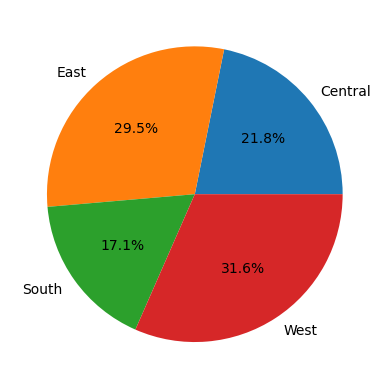

In [42]:
# Sales By Region
sales_region=df.groupby('region')['sales'].sum()
plt.pie(sales_region.values,labels=sales_region.index,autopct="%1.1f%%")